<a href="https://colab.research.google.com/github/karenmacambira/MVP/blob/main/MVP_Karen_AEPD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MVP Análise de Dados e Boas Práticas
Nome: Karen Macambira Ferreira

Matrícula: 4052024002461

Dataset: https://github.com/karenmacambira/MVP/blob/main/listings.zip

# Descrição do problema

O mercado de aluguéis por temporada no Rio de Janeiro, impulsionado por plataformas como o Airbnb, é altamente dinâmico e influenciado por fatores como localização, tipo de imóvel e comodidades. Entretanto, anfitriões e investidores frequentemente enfrentam desafios para:

* Definir preços competitivos que maximizem ocupação e lucratividade;

* Identificar quais comodidades ou características do imóvel justificam valores mais altos;

Problema Central:
"Como otimizar a precificação e a oferta de imóveis por temporada no Rio de Janeiro com base em dados históricos do Airbnb, considerando localização, tipo de imóvel e avaliações?"

# Hipóteses do problema

1. Como o preço médio varia entre imóveis inteiros, quartos privados e compartilhados nos diferentes bairros do Rio?

2. A proximidade de pontos turísticos (ex.: praias, Cristo Redentor) influencia o preço mais do que o tipo de imóvel?

3. Bairros com maior oferta de imóveis tendem a ter preços mais competitivos ou mais altos devido à visibilidade?

4. Imóveis com melhores avaliações mantêm preços mais altos mesmo em bairros menos valorizados?

5. Imóveis gerenciados por superhosts têm preços consistentemente mais altos do que os demais?

# Tipo de problema

O dataset listings é supervisionado porque contém uma variável alvo (o preço dos imóveis), que é o que estamos tentando prever. As variáveis independentes (como bairro, número de acomodações, avaliações e localização) servem como entrada para o modelo, enquanto o preço é a variável dependente ou target, sendo o principal foco da previsão. Como o modelo aprende a partir de exemplos com rótulos conhecidos (preço), trata-se de um problema supervisionado de regressão.

# Seleção de dados

Os dados foram extraídos do arquivo listings.csv no site: https://insideairbnb.com/get-the-data/ e salvos no github https://github.com/karenmacambira/MVP/blob/main/listings.zip

## Atributos do Dataset

* id                     : Identificador do imóvel.                                                              (int64 )
* latitude               : Latitude do imóvel.                                                                   (float64 )
* longitude              : Longitude do imóvel.                                                                  (float64 )
* accommodates           : Número de acomodações do imóvel.                                                      (int64   )
* price                  : Preço da diária do imóvel.                                                            (float64 )
* number_of_reviews      : Número de avaliações que o imóvel teve.                                               (int64   )
* review_scores_rating   : Nota baseada nas avaliações que o imóvel teve.                                        (float64 )
* reviews_per_month      : Média de avaliações por mês que o imóve recebeu.                                      (float64 )
* host_is_superhost      : Indica se o host é um superhost (t) ou não (f).                                       (object  )
* neighbourhood_cleansed : Bairro do imóvel.                                                                     (object  )
* room_type              : Tipo do imóvel. Pode ser  Entire home/apt, hotel room, private room ou shared room.   (object  )

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset listings.

In [283]:
# Importa as bibliotecas a serem utilizadas
!pip install pandasql
import ast
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import pandasql as ps
import seaborn as sns
import warnings
from collections import Counter
from geopy.distance import geodesic
from google.colab import files
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [284]:
# Ignora todos os warnings
warnings.filterwarnings('ignore')

In [285]:
# Caminho do arquivo no git
url = "https://raw.githubusercontent.com/karenmacambira/MVP/main/listings.zip"

In [286]:
# Descompacta arquivo e salva no dataframe df
df = pd.read_csv(url, compression='zip')

In [287]:
# Mostra as primeiras linhas
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,271975,https://www.airbnb.com/rooms/271975,20241227033009,2024-12-27,city scrape,Unbelievable Ocean View Apartment,NaN,"If you like hiking, you have to get on this tr...",https://a0.muscache.com/pictures/4563200/4ea0f...,1423140,...,4.67,4.33,4.00,NaN,f,1,1,0,0,0.05
1,272335,https://www.airbnb.com/rooms/272335,20241227033009,2024-12-28,city scrape,EXCELENTE APARTAMENTO EM COPACABANA,The apartment has 30m2 with connecting bedroom...,The beauty of my Copacabana beach. This needs...,https://a0.muscache.com/pictures/2828835/256cd...,7506316,...,4.97,4.97,4.86,NaN,t,2,2,0,0,2.31
2,272631,https://www.airbnb.com/rooms/272631,20241227033009,2024-12-28,city scrape,Comfort em Copacabana,The apartment is located in the Shopping dos A...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,1426830,...,5.00,4.97,4.94,NaN,t,5,3,2,0,0.25
3,273261,https://www.airbnb.com/rooms/273261,20241227033009,2024-12-28,city scrape,Amazing Huge Apartment in Leblon,"spacious apartment, with ocean view, super wel...",NaN,https://a0.muscache.com/pictures/4487816/a8d42...,533566,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
4,273363,https://www.airbnb.com/rooms/273363,20241227033009,2024-12-27,city scrape,Lindo quarto sossegado para temporada,We are happy to share our home with all those ...,Santa Teresa is a unique and very interesting ...,https://a0.muscache.com/pictures/miso/Hosting-...,556738,...,5.00,4.60,4.80,NaN,f,5,0,5,0,0.04


# Análise de Dados Exploratória

Nesta etapa de Análise de Dados Exploratória (EDA) vamos entender como os dados se relacionam, identificar possíveis valores faltantes, inconsistências, despadronizações e/ou outliers e tratar esses dados, para que o dataset tenha a maior qualidade possível.

## Total e Tipo das Instâncias

O dataset Listings possui 39.499 instâncias (observações) de imóveis com 74 características sobre eles. Porém, para elaborarmos uma análise mais enxuta, consideraremos somentes os dados relevantes para responder às hipóteses levantadas.

In [288]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 39499

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39499 entries, 0 to 39498
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            39499 non-null  int64  
 1   listing_url                                   39499 non-null  object 
 2   scrape_id                                     39499 non-null  int64  
 3   last_scraped                                  39499 non-null  object 
 4   source                                        39499 non-null  object 
 5   name                                          39499 non-null  object 
 6   description                                   38379 non-null  object 
 7   neighborhood_overview                         16880 non-null  object 
 8   picture_url                                   39499 non-null  object 
 9   host_i

Selecionando somente os dados relevantes para a análise

In [289]:
# Mantém apenas as colunas especificadas
df = df[['id', 'host_is_superhost', 'neighbourhood_cleansed', 'latitude', 'longitude',
         'room_type', 'accommodates', 'price', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month']]

# Mostra as colunas no dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39499 entries, 0 to 39498
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      39499 non-null  int64  
 1   host_is_superhost       38329 non-null  object 
 2   neighbourhood_cleansed  39499 non-null  object 
 3   latitude                39499 non-null  float64
 4   longitude               39499 non-null  float64
 5   room_type               39499 non-null  object 
 6   accommodates            39499 non-null  int64  
 7   price                   36644 non-null  object 
 8   number_of_reviews       39499 non-null  int64  
 9   review_scores_rating    29080 non-null  float64
 10  reviews_per_month       29080 non-null  float64
dtypes: float64(4), int64(3), object(4)
memory usage: 3.3+ MB
None


Ao selecionar os dados mais relevantes, já podemos observar que não existem mais colunas completamente nulas (count = 0):
* neighbourhood_group_cleansed;
* calculated_calendar;
* license.

Porém, é possível identificar que ainda existem dados nulos (count < 39.499) nas colunas abaixo:
* host_is_superhost (38.329);
* price (36.644);
* reviews_scores_rating (29.080);
* reviews_per_month (29.080).

Como os dados faltantes de host_is_superhost representam uma parte muito pequena do dataset (3%), vamos removê-los.

As duas últimas colunas acima são relacionadas às avaliações dos imóveis. Logo, existe grande chance das quantidades de registros iguais nas duas sejam dos mesmos registros.

Já os dados faltantes de preço são um pouco maiores que os de host_is_superhost (7%), então vamos analisar o % faltante por bairro:

In [290]:
# 1. Filtra apenas registros SEM preço (NaN)
df_sem_preco = df[df['price'].isna()]

# 2. Contar ocorrências por bairro (apenas bairros com dados faltantes)
faltantes_por_bairro = (
    df_sem_preco['neighbourhood_cleansed']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'imoveis_sem_preco'})
)

# 3. Calcula o total de imóveis por bairro (apenas para os bairros com faltantes)
total_por_bairro = (
    df[df['neighbourhood_cleansed'].isin(faltantes_por_bairro['neighbourhood_cleansed'])]
    ['neighbourhood_cleansed']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'total_imoveis'})
)

# 4. Junta e calcula a porcentagem
resultado = pd.merge(
    faltantes_por_bairro,
    total_por_bairro,
    on='neighbourhood_cleansed'
).assign(
    porcentagem_faltante=lambda x: round((x['imoveis_sem_preco'] / x['total_imoveis']) * 100, 2)
).sort_values('porcentagem_faltante', ascending=False)

# Salva como CSV
resultado.to_csv('resultado_completo.csv', index=False)

# Baixa o arquivo
files.download('resultado_completo.csv')

print(resultado)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   neighbourhood_cleansed  imoveis_sem_preco  total_imoveis  \
62             Água Santa                  2              4   
34                 Pavuna                  7             14   
82               Anchieta                  1              2   
51          Vigário Geral                  3              7   
65           Padre Miguel                  2              5   
..                    ...                ...            ...   
40                    Joá                  4            159   
52           Campo Grande                  3            127   
48              Itanhangá                  3            166   
49     Barra de Guaratiba                  3            171   
83              Pechincha                  1             66   

    porcentagem_faltante  
62                 50.00  
34                 50.00  
82                 50.00  
51                 42.86  
65                 40.00  
..                   ...  
40                  2.52  
52                  2.36  


Apesar de alguns bairros terem 50% de preços faltantes, são bairros afastados de pontos turísticos e pouco procurados.

Existem alguns bairros mais procurados com preços faltantes, mas o % é menor.

Por enquanto, vamos fazer as análises sem eles.

In [291]:
# Verifica a quantidade de dados nulos
print(f'Número de valores ausentes na coluna "price" antes de tratar: {df["price"].isna().sum()}')
print(f'Número de valores ausentes na coluna "host_is_superhost" antes de tratar: {df["host_is_superhost"].isna().sum()}')

# Limpa os dados nulos
df = df.dropna(subset=['price', 'host_is_superhost'])

# Verifica a quantidade de dados nulos após a limpeza
print(f'Número de valores ausentes na coluna "price" depois de tratar: {df["price"].isna().sum()}')
print(f'Número de valores ausentes na coluna "host_is_superhost" depois de tratar: {df["host_is_superhost"].isna().sum()}')

Número de valores ausentes na coluna "price" antes de tratar: 2855
Número de valores ausentes na coluna "host_is_superhost" antes de tratar: 1170
Número de valores ausentes na coluna "price" depois de tratar: 0
Número de valores ausentes na coluna "host_is_superhost" depois de tratar: 0


Os dados de preço (price) são do tipo object porque estão com o símbolo $.
Vamos transformá-los em float:


In [292]:
# Remove o símbolo $ e converte para float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Mostra as colunas do dataset com price tratada
print(df.info())

# Mostra as primeiras linhas
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 35582 entries, 0 to 39498
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      35582 non-null  int64  
 1   host_is_superhost       35582 non-null  object 
 2   neighbourhood_cleansed  35582 non-null  object 
 3   latitude                35582 non-null  float64
 4   longitude               35582 non-null  float64
 5   room_type               35582 non-null  object 
 6   accommodates            35582 non-null  int64  
 7   price                   35582 non-null  float64
 8   number_of_reviews       35582 non-null  int64  
 9   review_scores_rating    26160 non-null  float64
 10  reviews_per_month       26160 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 3.3+ MB
None


,id,host_is_superhost,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,price,number_of_reviews,review_scores_rating,reviews_per_month
0,271975,f,Vidigal,-22.99508,-43.23604,Entire home/apt,4,236.0,7,4.14,0.05
1,272335,f,Copacabana,-22.96230,-43.17389,Entire home/apt,4,723.0,367,4.92,2.31
2,272631,t,Copacabana,-22.96750,-43.18666,Private room,2,1146.0,32,5.00,0.25
3,273261,f,Leblon,-22.98632,-43.22936,Entire home/apt,6,6742.0,0,NaN,NaN
4,273363,f,Santa Teresa,-22.91825,-43.17872,Private room,1,61.0,5,5.00,0.04


Vamos analisar as estatísticas descritivas:

In [293]:
# Desconsidera colunas que não faz sentido analisar as estatísticas
df.drop(columns=['id','latitude','longitude']).describe()

,accommodates,price,number_of_reviews,review_scores_rating,reviews_per_month
count,35582.000000,35582.000000,35582.000000,26160.000000,26160.000000
mean,4.014642,1227.606796,23.176381,4.815606,1.162340
std,2.307429,3815.245715,45.442370,0.345369,1.266114
min,1.000000,33.000000,0.000000,0.000000,0.010000
25%,2.000000,400.000000,0.000000,4.770000,0.250000
50%,4.000000,721.000000,5.000000,4.920000,0.730000
75%,5.000000,1200.000000,25.000000,5.000000,1.680000
max,16.000000,500000.000000,710.000000,5.000000,14.620000


Identificado outlier no preço = R$ 500.000,00. Como esse dataset é do Airbnb, os preços são referentes a uma diária, o que nos faz chegar à conclusão de que o preço está errado.

Vamos gerar o bloxpot com os bairros para analisar o comportamento dos preços.


Aviso: O gráfico ficou comprometido devido à quantidade de dados.


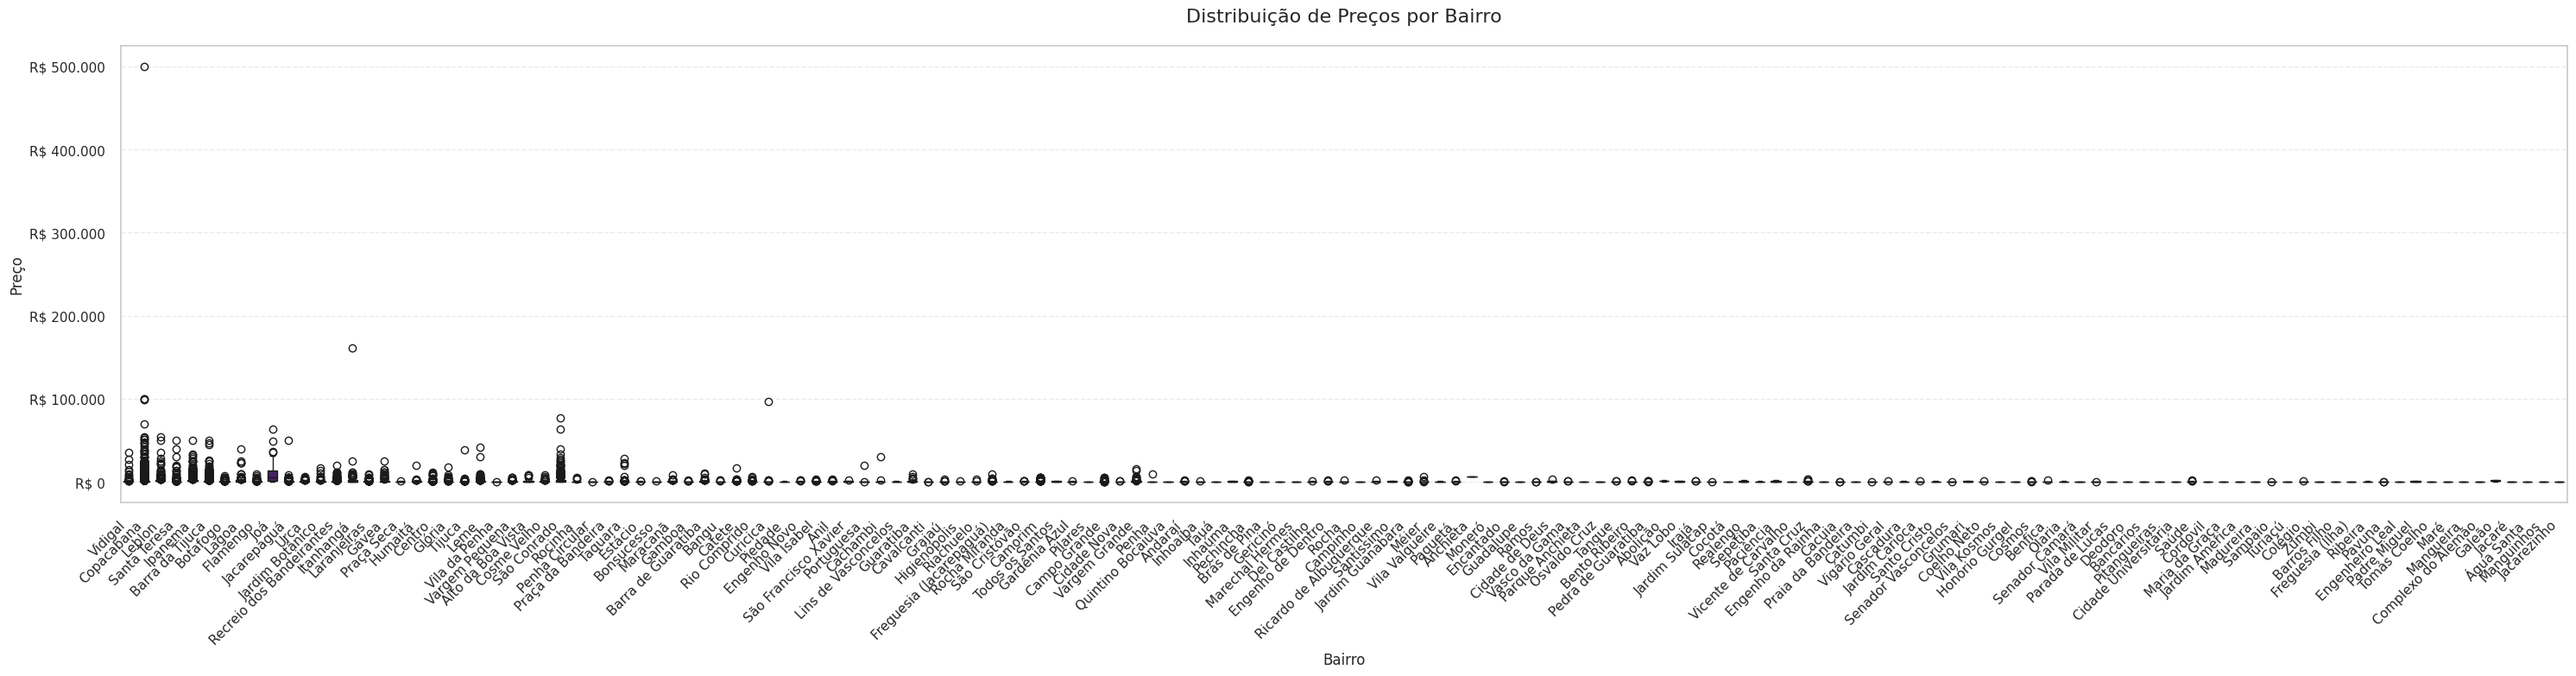

In [294]:
# Formatação para Reais
def formato_reais(x, pos):
    return f'R$ {x:,.0f}'.replace(",", ".")  # Ex: R$ 300.000

formatter = FuncFormatter(formato_reais)

# Configuração do gráfico
plt.figure(figsize=(30, 8))

# Boxplot com cores por bairro
boxplot = sns.boxplot(
    y='price',
    x='neighbourhood_cleansed',
    data=df,
    palette='viridis',  # Altere para 'tab20', 'husl', ou outra paleta
    width=0.6
)

# Formatação do eixo Y
plt.gca().yaxis.set_major_formatter(formatter)

# Títulos e labels
plt.title('Distribuição de Preços por Bairro', fontsize=16, pad=20)
plt.xlabel('Bairro', fontsize=12)
plt.ylabel('Preço', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Correção para extração de cores
bairros = df['neighbourhood_cleansed'].unique()

# Verifica se temos boxes desenhadas
if len(boxplot.artists) > 0:
    # Extrai cores das boxes existentes
    cores = [boxplot.artists[i].get_facecolor() for i in range(len(boxplot.artists))]

    # Cria legendas apenas para os bairros com boxes
    legend_patches = [
        Patch(facecolor=cores[i], label=bairros[i])
        for i in range(len(boxplot.artists))
    ]

    plt.legend(
        handles=legend_patches,
        title='Bairros',
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        fontsize=10,
        frameon=False
    )
else:
    print("Aviso: O gráfico ficou comprometido devido à quantidade de dados.")

plt.tight_layout()
plt.show()

Apesar do gráfico ter ficado comprometido devido à quantidade de dados, conseguimos visualizar que imóveis acima de R$ 100.000,00 são outliers muito altos. Vamos tentar gerar o gráfico acima com os imóveis abaixo desse valor.

Aviso: O gráfico ficou comprometido devido à quantidade de dados.


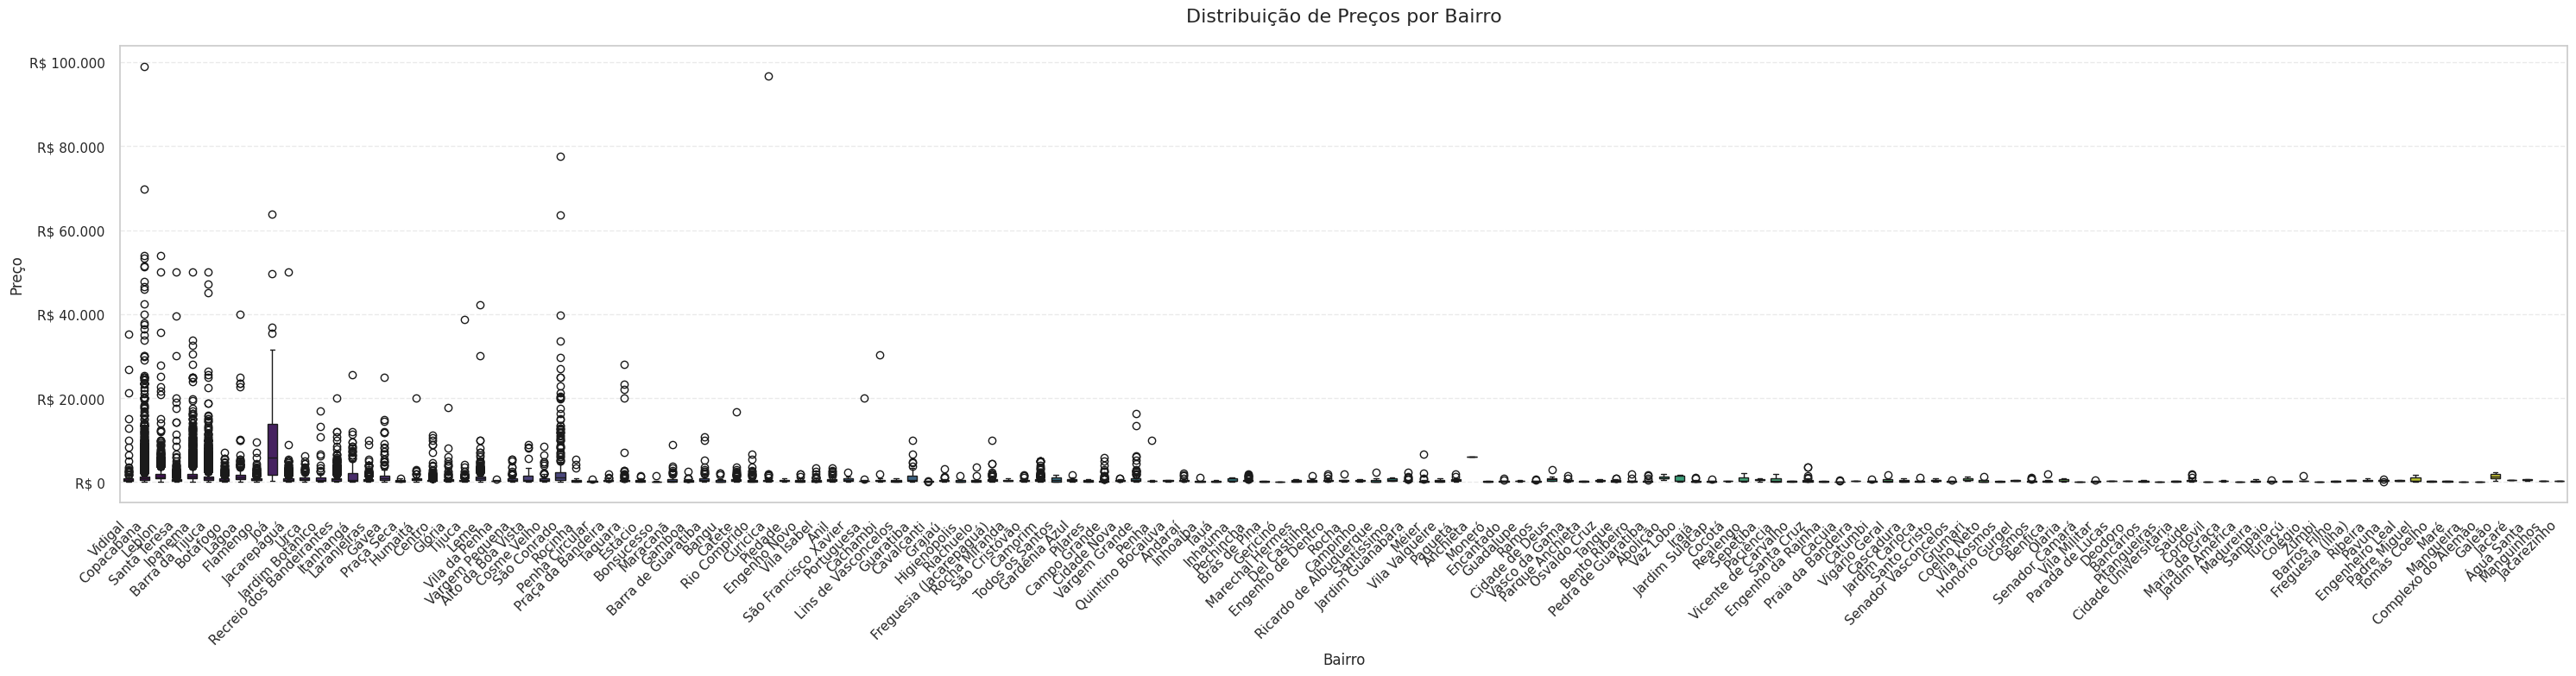

In [295]:
# Filtra o dataset com imóveis até R$ 99.999,99
query = "SELECT * FROM df WHERE price <= 99999.99"

# Salva o resultado no df_filtrado
df = ps.sqldf(query, locals())

# Configuração do gráfico
plt.figure(figsize=(30, 8))

# Boxplot com cores por bairro
boxplot = sns.boxplot(
    y='price',
    x='neighbourhood_cleansed',
    data=df,
    palette='viridis',  # Altere para 'tab20', 'husl', ou outra paleta
    width=0.6
)

# Formatação do eixo Y
plt.gca().yaxis.set_major_formatter(formatter)

# Títulos e labels
plt.title('Distribuição de Preços por Bairro', fontsize=16, pad=20)
plt.xlabel('Bairro', fontsize=12)
plt.ylabel('Preço', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Correção para extração de cores
bairros = df['neighbourhood_cleansed'].unique()

# Verifica se temos boxes desenhadas
if len(boxplot.artists) > 0:
    # Extrai cores das boxes existentes
    cores = [boxplot.artists[i].get_facecolor() for i in range(len(boxplot.artists))]

    # Cria legendas apenas para os bairros com boxes
    legend_patches = [
        Patch(facecolor=cores[i], label=bairros[i])
        for i in range(len(boxplot.artists))
    ]

    plt.legend(
        handles=legend_patches,
        title='Bairros',
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        fontsize=10,
        frameon=False
    )
else:
    print("Aviso: O gráfico ficou comprometido devido à quantidade de dados.")

plt.tight_layout()
plt.show()

Vamos verificar qual o valor máximo de 99% dos imóveis, para ver se a diferença entre as estatísticas descritivas do dataset completo e do dataset sem esses registros nos mostra alguma distorção.

In [296]:
limite = df["price"].quantile(0.99)
acima = (df["price"] > limite).sum()
total = df["price"].notna().sum()
porcentagem = (acima / total) * 100

print(f"{acima} imóveis ({porcentagem:.2f}%) estão acima de R$ {limite:,.2f}")

356 imóveis (1.00%) estão acima de R$ 9,945.10


In [297]:
# Filtra o dataset com imóveis até R$ 9.945,10
query = "SELECT * FROM df WHERE price <= 9945.10"

# Salva o resultado no df_filtrado
df_preco_filtrado = ps.sqldf(query, locals())

In [298]:
# Dados completos
desc1 = df.drop(columns=['id', 'latitude','longitude']).describe()

# Dados filtrados
desc2 = df_preco_filtrado.drop(columns=['id', 'latitude','longitude']).describe()

# Comparação dos dados comletos com os filtrados
variacao_pct = ((desc1 - desc2) / desc1) * 100

#display(variacao_pct.round(2))
display(variacao_pct)

,accommodates,price,number_of_reviews,review_scores_rating,reviews_per_month
count,1.000618,1.000618,1.000618,0.519878,0.519878
mean,1.162523,15.730736,-0.639840,0.001977,-0.246219
std,2.905749,56.853975,-0.326219,0.077621,-0.129659
min,0.000000,0.000000,NaN,NaN,0.000000
25%,0.000000,0.000000,NaN,0.000000,0.000000
50%,0.000000,0.970874,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,-0.595238
max,0.000000,89.970707,0.000000,0.000000,0.000000


As maiores variações foram na média e no desvio padrão do preço, que é normal acontecer quando temos outliers muito discrepantes. Ao retirarmos esses outliers, podemos verificar que a variação dos demais dados é inferior a 5%, que nos indica que não houve distorção no resultado.

Com isso, vamos seguir com esse filtro nos preços.

Agora vamos analisar os dados faltantes:

<Axes: >

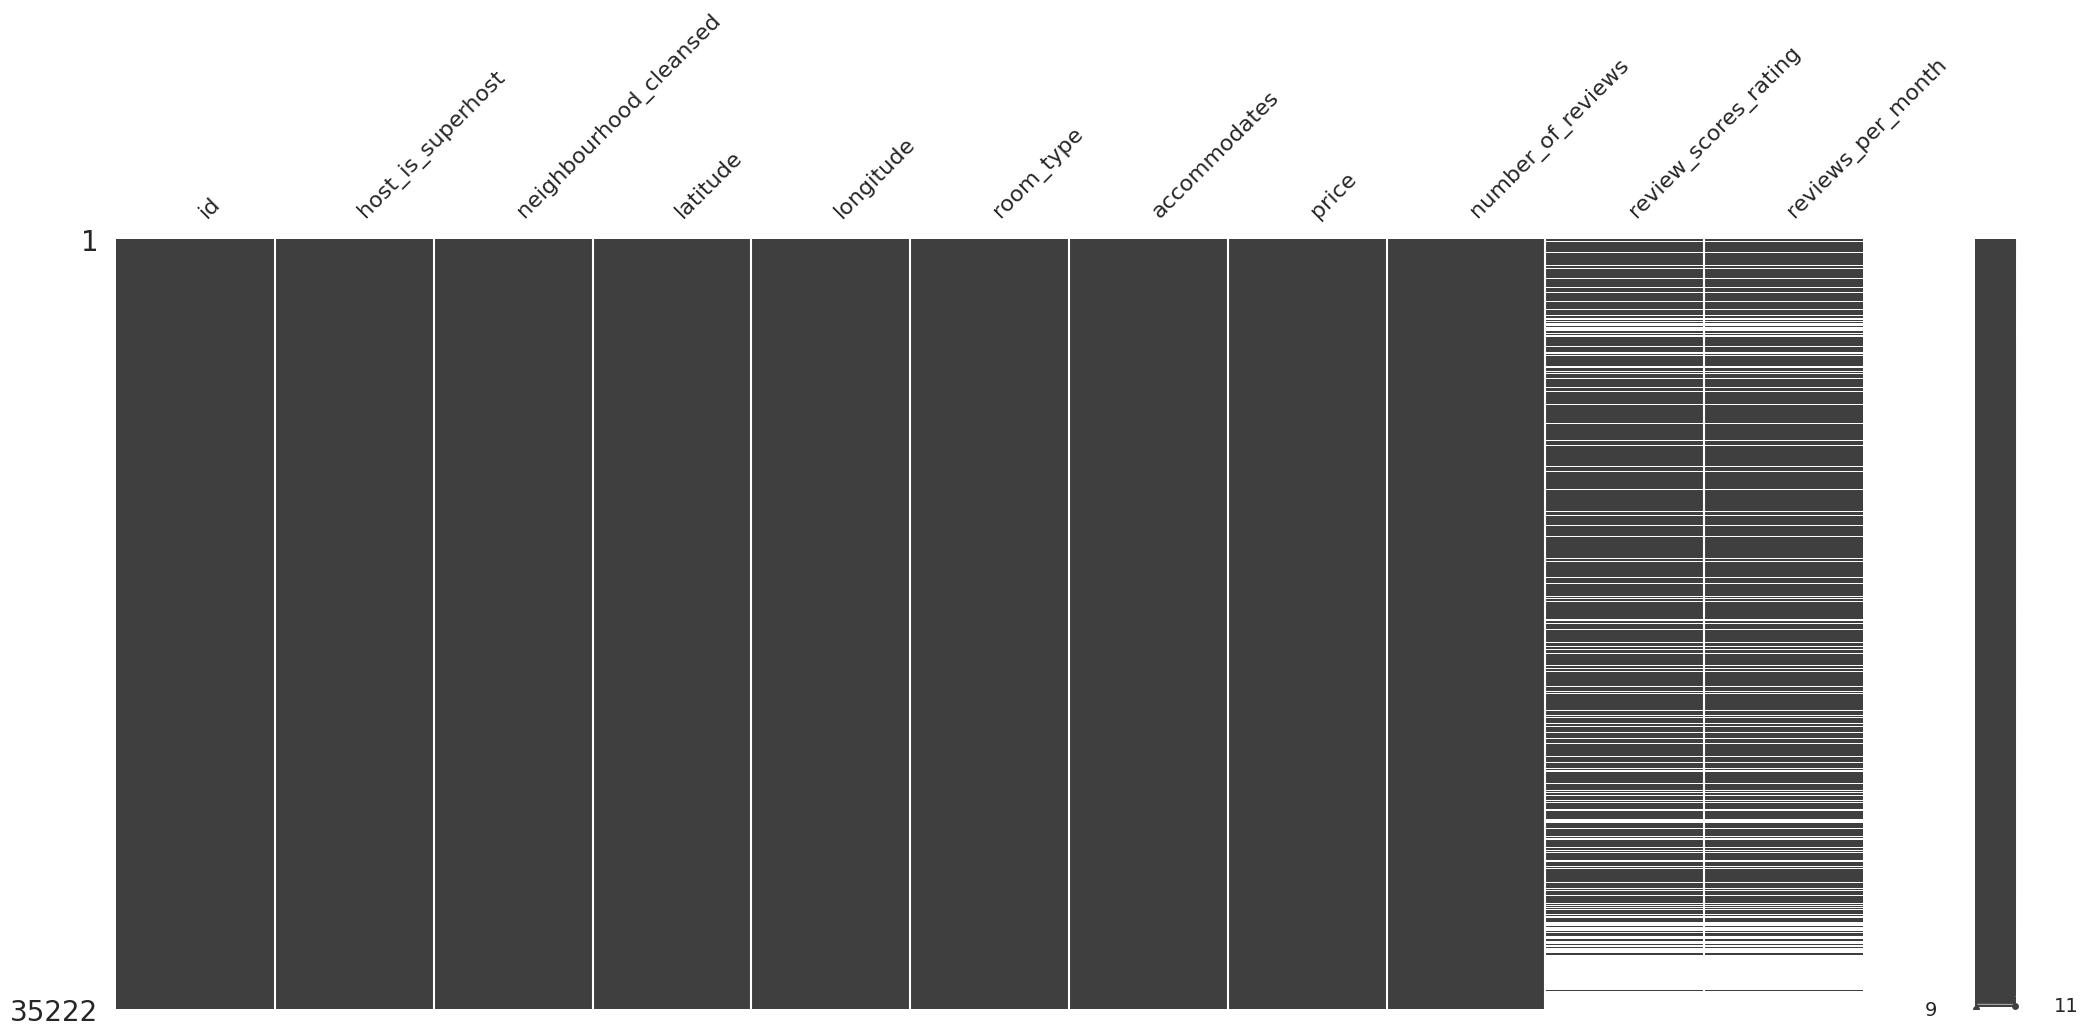

In [299]:
# Função para visualizar o padrão dos dados faltantes
msno.matrix(df_preco_filtrado)

Podemos identificar um padrão de dados faltantes em informações de avaliações, o que nos leva a pensar que esses imóveis ainda não foram avaliados.

Vamos retirar esses registros e comparar novamente os datasets.

Vamos comparar as estatísticas entre o dataset completo (com registros incompletos) e o dataset filtrado (apenas registros completos):

<Axes: >

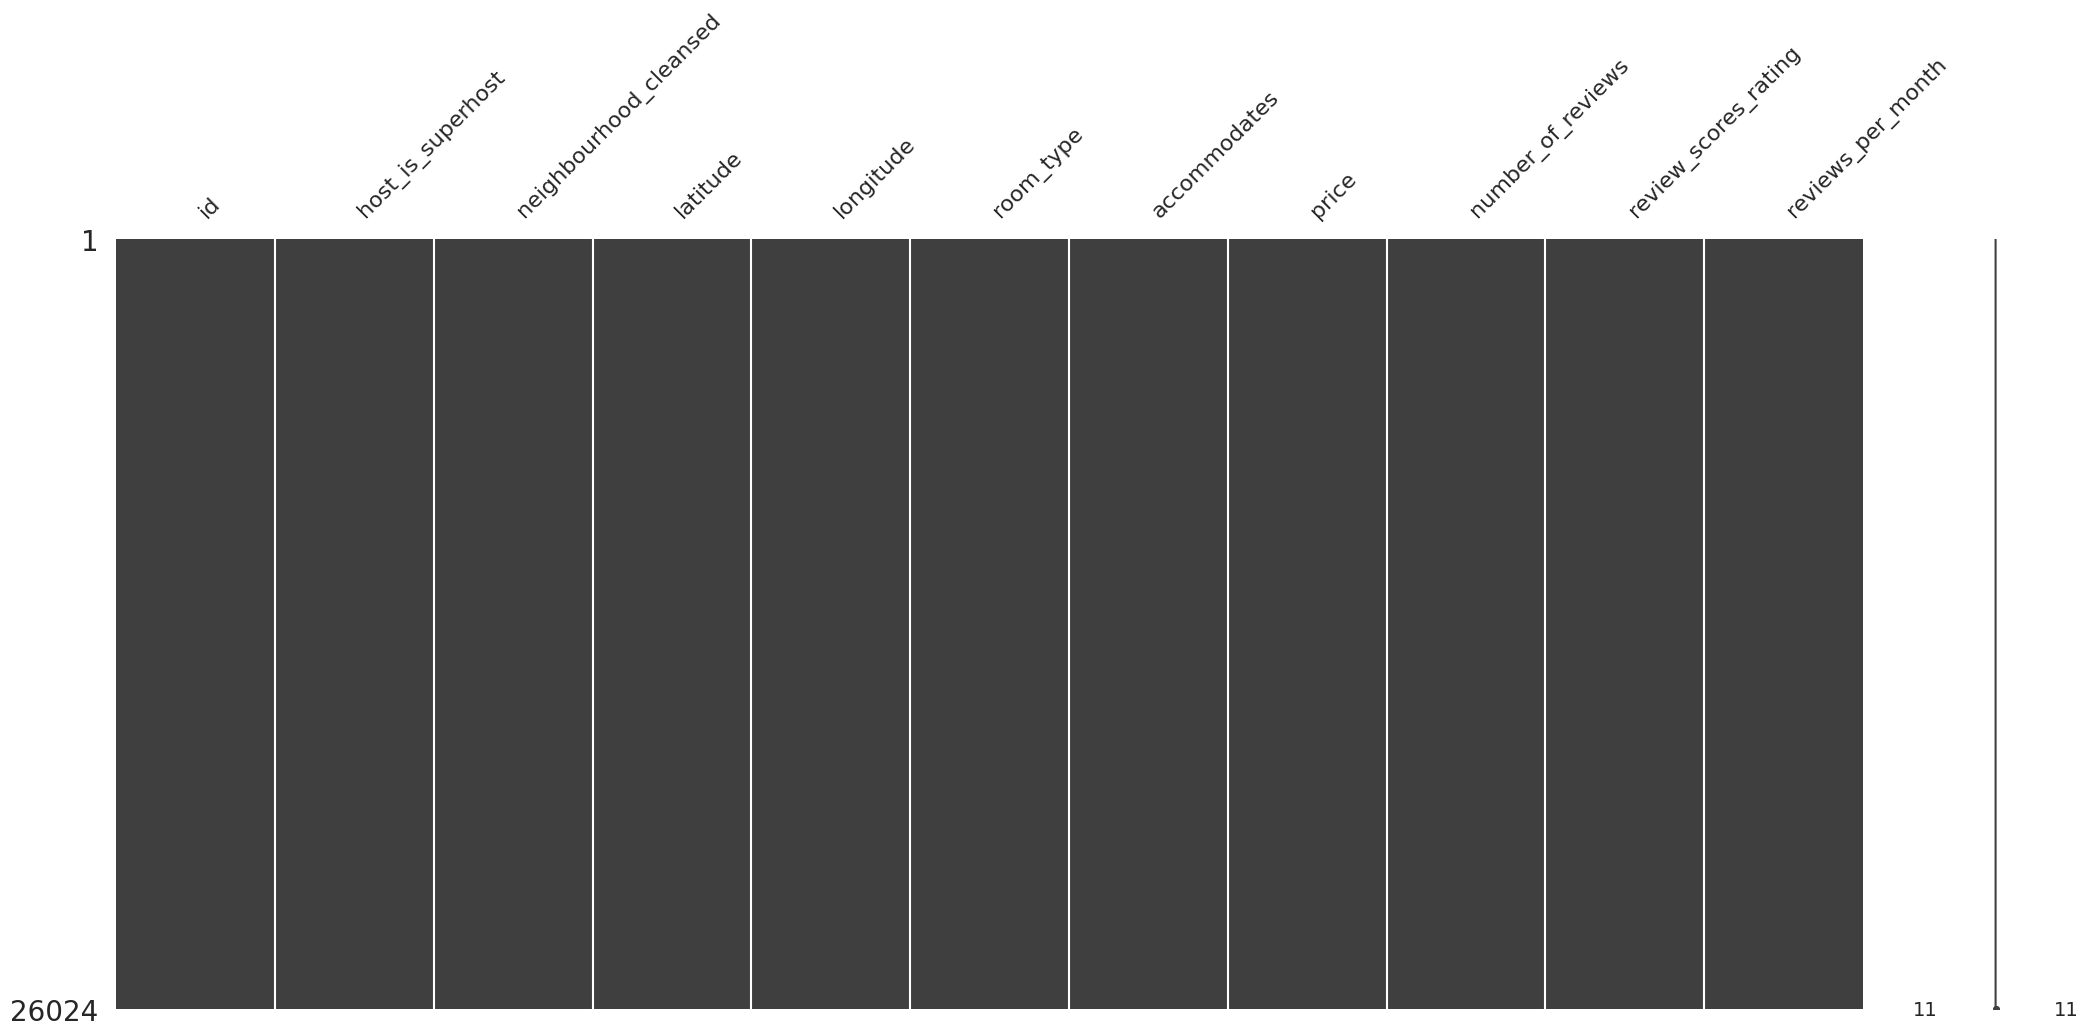

In [300]:
# Filtra o dataset somente com os registros preenchidos
query = "SELECT * FROM df_preco_filtrado WHERE review_scores_rating is not null and reviews_per_month is not null"
df_filtrado = ps.sqldf(query, locals())

# Função para visualizar o padrão sem os dados faltantes
msno.matrix(df_filtrado)

Agora vamos comparar as estatísticas entre o dataset completo (com registros incompletos) e o dataset filtrado (apenas registros completos):

In [301]:
# Dados sem os outliers e com os dados faltantes de reviews
desc1 = df_preco_filtrado.drop(columns=['id', 'latitude','longitude']).describe()

# Dados filtrados removendo os dados faltantes de reviews
desc2 = df_filtrado.drop(columns=['id', 'latitude','longitude']).describe()

# Comparação dos dados antes e depois da remoção dos dados faltantes
variacao_pct = ((desc1 - desc2) / desc1) * 100

#display(variacao_pct.round(2))
display(variacao_pct)

,accommodates,price,number_of_reviews,review_scores_rating,reviews_per_month
count,26.114360,26.114360,26.114360,0.0,0.0
mean,2.180269,5.949216,-35.344298,0.0,0.0
std,5.681553,10.293679,-10.825260,0.0,0.0
min,0.000000,0.000000,-inf,NaN,0.0
25%,0.000000,0.000000,-inf,0.0,0.0
50%,0.000000,1.960784,-140.000000,0.0,0.0
75%,0.000000,5.750000,-48.000000,0.0,0.0
max,0.000000,0.000000,0.000000,0.0,0.0


Podemos identificar variações acima de 5% na média, desvio padrão e percentil 75 dos preços. Por enquanto, vamos manter os imóveis sem avaliações e vamos imputar as seguintes informações:
* review_scores_rating = NaN (Not a Number) - Como é uma nota referente às avaliações e não existem avaliações, não podemos imputar um valor.
* reviews_per_month = 0.0 (Zero) - Como é a média de avaliações por mês e não existem avaliações, faz sentido imputarmos o valor zero.

Sabemos que não houve avaliação porque, para esses imóveis, o número de avaliações (number_of_reviews) é igual a 0 (zero). Esse é o critério para imputarmos os dados especificados acima.

In [302]:
# Só aplica NaN ou zero onde não há avaliações
df_preco_filtrado.loc[df_preco_filtrado['number_of_reviews'] == 0, 'review_scores_rating'] = np.nan
df_preco_filtrado.loc[df_preco_filtrado['number_of_reviews'] == 0, 'reviews_per_month'] = 0.0

# Resultado:
df_preco_filtrado.head()

,id,host_is_superhost,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,price,number_of_reviews,review_scores_rating,reviews_per_month
0,271975,f,Vidigal,-22.99508,-43.23604,Entire home/apt,4,236.0,7,4.14,0.05
1,272335,f,Copacabana,-22.96230,-43.17389,Entire home/apt,4,723.0,367,4.92,2.31
2,272631,t,Copacabana,-22.96750,-43.18666,Private room,2,1146.0,32,5.00,0.25
3,273261,f,Leblon,-22.98632,-43.22936,Entire home/apt,6,6742.0,0,NaN,0.00
4,273363,f,Santa Teresa,-22.91825,-43.17872,Private room,1,61.0,5,5.00,0.04


Vamos adicionar a coluna zona para identificar as zonas dos bairros:

In [303]:
# Dicionário de bairros e zonas
zona_por_bairro = {
    # Zona Sul
    'Copacabana': 'Zona Sul',
    'Ipanema': 'Zona Sul',
    'Leblon': 'Zona Sul',
    'Leme': 'Zona Sul',
    'Botafogo': 'Zona Sul',
    'Flamengo': 'Zona Sul',
    'Gávea': 'Zona Sul',
    'Jardim Botânico': 'Zona Sul',
    'Lagoa': 'Zona Sul',
    'Catete': 'Zona Sul',
    'Cosme Velho': 'Zona Sul',
    'Urca': 'Zona Sul',
    'Santa Teresa': 'Zona Sul',
    'Humaitá': 'Zona Sul',
    'Glória': 'Zona Sul',
    'Laranjeiras': 'Zona Sul',
    'São Conrado': 'Zona Sul',
    'Vidigal': 'Zona Sul',
    'Alto da Boa Vista': 'Zona Sul',

    # Zona Norte
    'Tijuca': 'Zona Norte',
    'Maracanã': 'Zona Norte',
    'Vila Isabel': 'Zona Norte',
    'Grajaú': 'Zona Norte',
    'Méier': 'Zona Norte',
    'Rio Comprido': 'Zona Norte',
    'Andaraí': 'Zona Norte',
    'Riachuelo': 'Zona Norte',
    'Encantado': 'Zona Norte',
    'Piedade': 'Zona Norte',
    'Madureira': 'Zona Norte',
    'Pilares': 'Zona Norte',
    'Bento Ribeiro': 'Zona Norte',
    'Rocha': 'Zona Norte',
    'Engenho Novo': 'Zona Norte',
    'Todos os Santos': 'Zona Norte',
    'Vaz Lobo': 'Zona Norte',
    'Quintino Bocaiúva': 'Zona Norte',
    'Cascadura': 'Zona Norte',
    'Campinho': 'Zona Norte',
    'Honório Gurgel': 'Zona Norte',
    'Tomás Coelho': 'Zona Norte',
    'Engenho da Rainha': 'Zona Norte',
    'Olaria': 'Zona Norte',
    'Inhaúma': 'Zona Norte',
    'Del Castilho': 'Zona Norte',
    'Maria da Graça': 'Zona Norte',
    'Bonsucesso': 'Zona Norte',
    'Ramos': 'Zona Norte',
    'Penha': 'Zona Norte',
    'Brás de Pina': 'Zona Norte',
    'Vigário Geral': 'Zona Norte',
    'Anchieta': 'Zona Norte',
    'Parada de Lucas': 'Zona Norte',
    'Cordovil': 'Zona Norte',
    'Parque Anchieta': 'Zona Norte',
    'Pavuna': 'Zona Norte',
    'Irajá': 'Zona Norte',
    'Vicente de Carvalho': 'Zona Norte',
    'Coelho Neto': 'Zona Norte',
    'Acari': 'Zona Norte',
    'Barros Filho': 'Zona Norte',
    'Costa Barros': 'Zona Norte',
    'Guadalupe': 'Zona Norte',
    'Deodoro': 'Zona Norte',
    'Jardim América': 'Zona Norte',
    'Marechal Hermes': 'Zona Norte',
    'Vila Militar': 'Zona Norte',
    'Realengo': 'Zona Norte',
    'Padre Miguel': 'Zona Norte',
    'Bangu': 'Zona Norte',
    'Senador Camará': 'Zona Norte',
    'Santíssimo': 'Zona Norte',
    'Campo Grande': 'Zona Norte',
    'Senador Vasconcelos': 'Zona Norte',
    'Inhoaíba': 'Zona Norte',
    'Cosmos': 'Zona Norte',
    'Paciência': 'Zona Norte',
    'Santa Cruz': 'Zona Norte',
    'Sepetiba': 'Zona Norte',
    'Vila da Penha': 'Zona Norte',
    'Penha Circular': 'Zona Norte',
    'Praça da Bandeira': 'Zona Norte',
    'São Francisco Xavier': 'Zona Norte',
    'Cachambi': 'Zona Norte',
    'Lins de Vasconcelos': 'Zona Norte',
    'Cavalcanti': 'Zona Norte',
    'Higienópolis': 'Zona Norte',
    'Rocha Miranda': 'Zona Norte',
    'Abolição': 'Zona Norte',
    'Água Santa': 'Zona Norte',
    'Cidade Universitária': 'Zona Norte',
    'Colégio': 'Zona Norte',
    'Engenheiro Leal': 'Zona Norte',
    'Engenho de Dentro': 'Zona Norte',
    'Jacaré': 'Zona Norte',
    'Mangueira': 'Zona Norte',
    'Osvaldo Cruz': 'Zona Norte',
    'Ricardo de Albuquerque': 'Zona Norte',
    'Sampaio': 'Zona Norte',
    'Turiaçú': 'Zona Norte',
    'Vasco da Gama': 'Zona Norte',
    'Vila Kosmos': 'Zona Norte',

    # Zona Oeste
    'Barra da Tijuca': 'Zona Oeste',
    'Recreio dos Bandeirantes': 'Zona Oeste',
    'Jacarepaguá': 'Zona Oeste',
    'Taquara': 'Zona Oeste',
    'Freguesia (Jacarepaguá)': 'Zona Oeste',
    'Pechincha': 'Zona Oeste',
    'Anil': 'Zona Oeste',
    'Gardênia Azul': 'Zona Oeste',
    'Cidade de Deus': 'Zona Oeste',
    'Curicica': 'Zona Oeste',
    'Vargem Grande': 'Zona Oeste',
    'Vargem Pequena': 'Zona Oeste',
    'Camorim': 'Zona Oeste',
    'Joá': 'Zona Oeste',
    'Itanhangá': 'Zona Oeste',
    'Grumari': 'Zona Oeste',
    'Guaratiba': 'Zona Oeste',
    'Barra de Guaratiba': 'Zona Oeste',
    'Pedra de Guaratiba': 'Zona Oeste',
    'Vila Valqueire': 'Zona Oeste',
    'Tanque': 'Zona Oeste',
    'Praça Seca': 'Zona Oeste',
    'Jardim Sulacap': 'Zona Oeste',
    'Gericinó': 'Zona Oeste',

    # Centro
    'Centro': 'Centro',
    'Saúde': 'Centro',
    'Gamboa': 'Centro',
    'Santo Cristo': 'Centro',
    'Cidade Nova': 'Centro',
    'Estácio': 'Centro',
    'Benfica': 'Centro',
    'São Cristóvão': 'Centro',
    'Catumbi': 'Centro',
    'Lapa': 'Centro',

    # Ilhas
    'Paquetá': 'Ilha',
    'Ilha do Governador': 'Ilha',
    'Freguesia (Ilha)': 'Ilha',
    'Jardim Carioca': 'Ilha',
    'Bancários': 'Ilha',
    'Cacuia': 'Ilha',
    'Moneró': 'Ilha',
    'Portuguesa': 'Ilha',
    'Tauá': 'Ilha',
    'Pitangueiras': 'Ilha',
    'Zumbi': 'Ilha',
    'Cocotá': 'Ilha',
    'Praia da Bandeira': 'Ilha',
    'Galeão': 'Ilha',
    'Jardim Guanabara': 'Ilha',
    'Ribeira': 'Ilha',

    # Favelas/Comunidades
    'Rocinha': 'Zona Sul',
    'Complexo do Alemão': 'Zona Norte',
    'Cidade de Deus': 'Zona Oeste',
    'Manguinhos': 'Zona Norte',
    'Jacarezinho': 'Zona Norte',
    'Maré': 'Zona Norte'
}

# Função para mapear os bairros para zonas
def mapear_zona(bairro):
    return zona_por_bairro.get(bairro, 'Zona Não Especificada')  # Retorna 'Zona Não Especificada' se o bairro não estiver no dicionário

# Cria a nova coluna 'zona' aplicando a função de mapeamento
df_preco_filtrado['zona'] = df_preco_filtrado['neighbourhood_cleansed'].map(mapear_zona)

# Verifique os resultados
print(df_preco_filtrado[['neighbourhood_cleansed', 'zona']].head(10))


  neighbourhood_cleansed      zona
0                Vidigal  Zona Sul
1             Copacabana  Zona Sul
2             Copacabana  Zona Sul
3                 Leblon  Zona Sul
4           Santa Teresa  Zona Sul
5                 Leblon  Zona Sul
6           Santa Teresa  Zona Sul
7           Santa Teresa  Zona Sul
8             Copacabana  Zona Sul
9             Copacabana  Zona Sul


# Respondendo às hipóteses



1. Como o preço médio varia entre imóveis inteiros, quartos privados e compartilhados nas diferentes zonas do Rio?

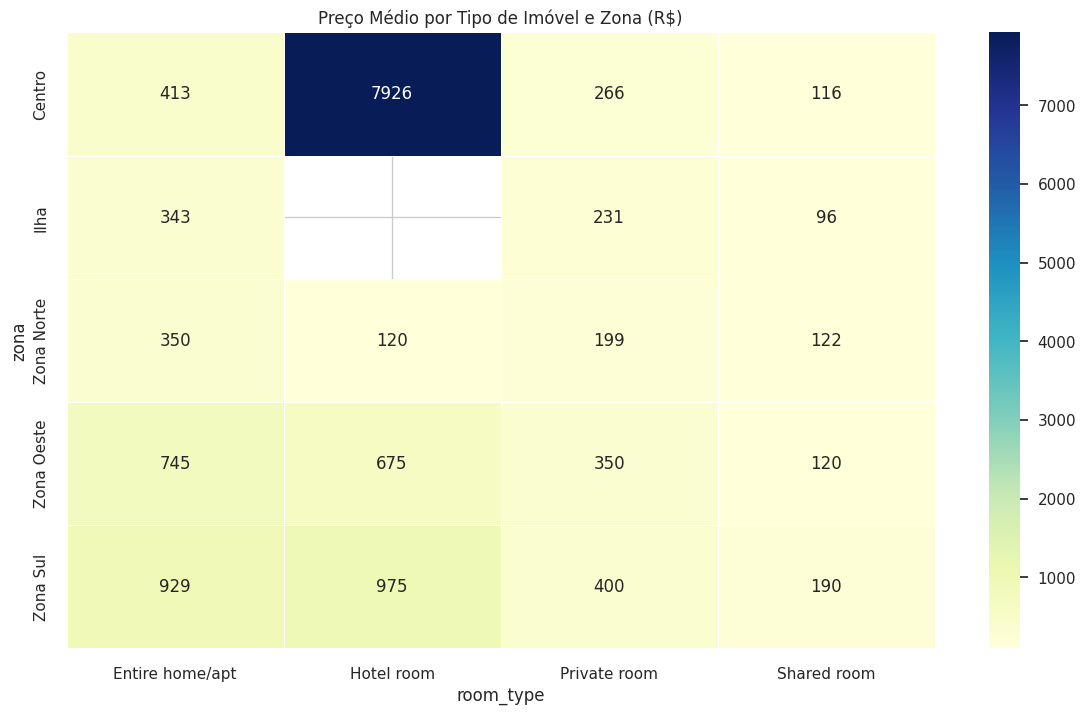

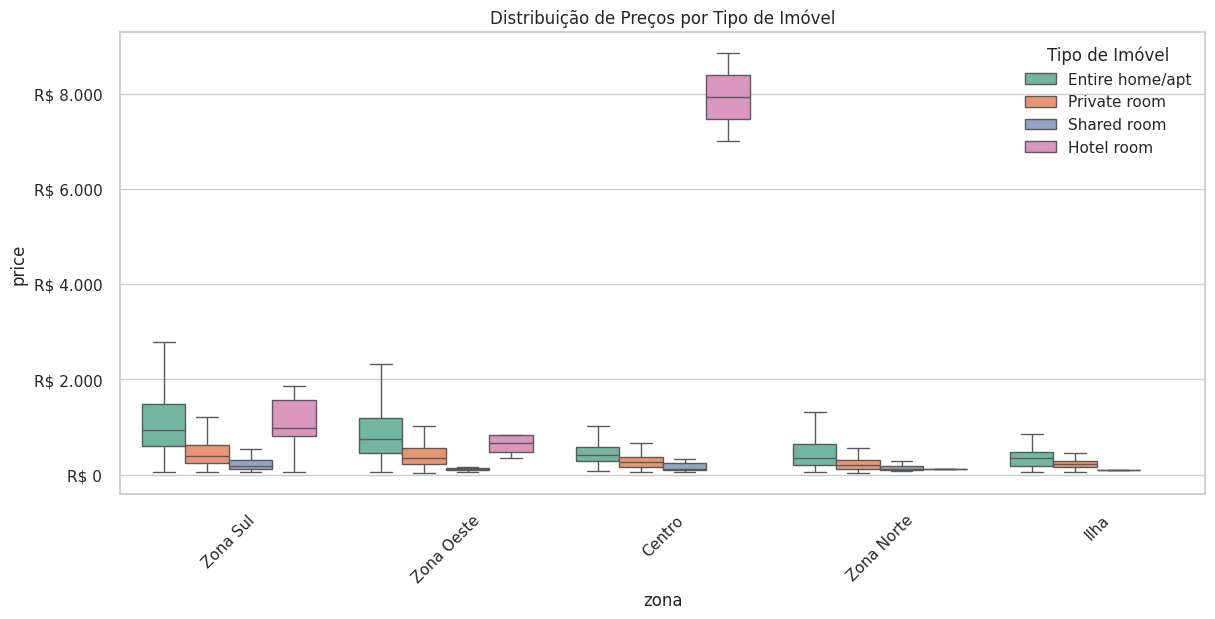

In [304]:
# Heatmap de preços médios
pivot_table = df_preco_filtrado.pivot_table(
    values='price',
    index='zona',
    columns='room_type',
    aggfunc='median'
)
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Preço Médio por Tipo de Imóvel e Zona (R$)")
plt.show()

# Boxplot comparativo
plt.figure(figsize=(14, 6))
sns.boxplot(
    x='zona',
    y='price',
    hue='room_type',
    data=df_preco_filtrado,
    palette="Set2",
    showfliers=False
)
plt.gca().yaxis.set_major_formatter(formatter)
plt.title("Distribuição de Preços por Tipo de Imóvel")
plt.xticks(rotation=45)
plt.legend(title="Tipo de Imóvel")
plt.show()

Ao verificar quais hotéis estão puxando o preço do centro para cima, identificamos dois registros do Selina, na Lapa, cujos IDs são 38850451 (7,002.00) e 38865363 (8,851.00). Por isso que a média dos hotéis no Centro estava alta. Esse hotel não existe mais na Lapa e, devido a isso, excluiremos seus registros.

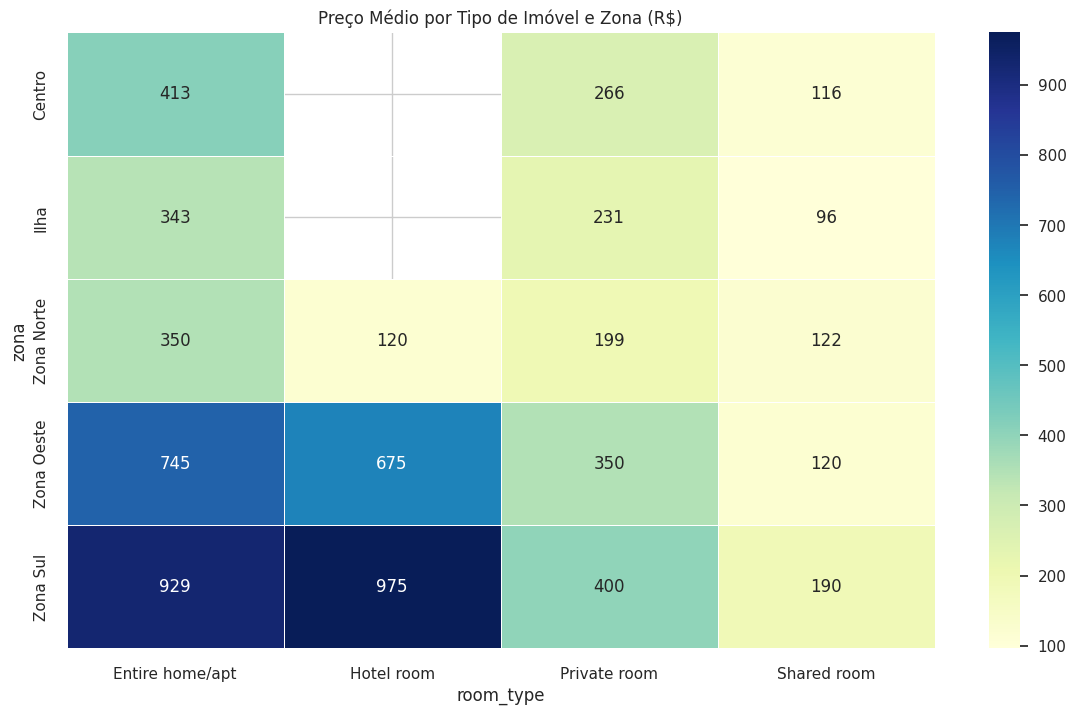

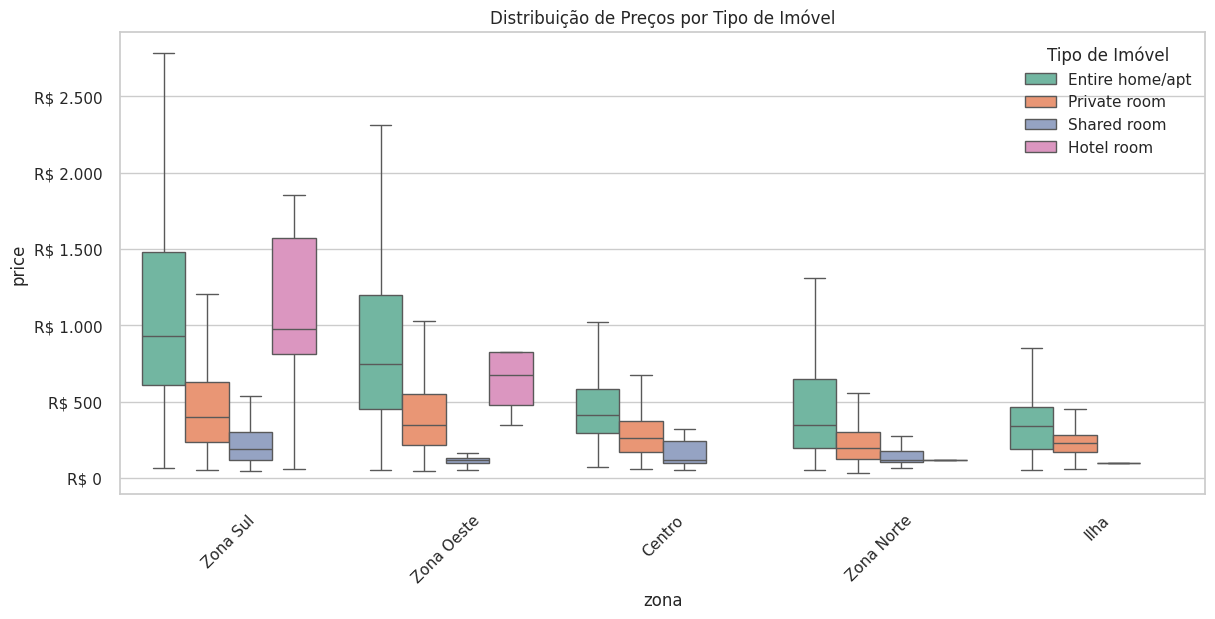

In [305]:
# Exclui os IDs do hotel Selina na Lapa
query = "SELECT * FROM df_preco_filtrado WHERE id not in ('38850451','38865363')"
df_preco_filtrado = ps.sqldf(query, locals())

# Heatmap de preços médios
pivot_table = df_preco_filtrado.pivot_table(
    values='price',
    index='zona',
    columns='room_type',
    aggfunc='median'
)
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Preço Médio por Tipo de Imóvel e Zona (R$)")
plt.show()

# Boxplot comparativo
plt.figure(figsize=(14, 6))
sns.boxplot(
    x='zona',
    y='price',
    hue='room_type',
    data=df_preco_filtrado,
    palette="Set2",
    showfliers=False
)
plt.gca().yaxis.set_major_formatter(formatter)
plt.title("Distribuição de Preços por Tipo de Imóvel")
plt.xticks(rotation=45)
plt.legend(title="Tipo de Imóvel")
plt.show()

Sem os outliers do Selina, a visualização do bloxpot ficou melhor.

Podemos perceber que, em todas as zonas do Rio, a quantidade e o preço de imóveis inteiros (entire home/apt) é maior que a quantidade e o preço de quartos privados (private room) e compartilhados (shared room).

A concentração de hotéis (hotel room) é maior na zona sul e na zona oeste e os valores das diárias são similares aos valores de imóveis inteiros.

Devido à complexidade encontrada nas análises e ao curto tempo para terminar o MVP, vamos considerar somente os 10 bairros mais importantes:

Top 10 Bairros Mais Importantes:


,neighbourhood_cleansed,indice_importancia
77,Leblon,8668.667467
32,Copacabana,8580.632253
13,Botafogo,8573.295985
7,Barra da Tijuca,8562.625050
45,Flamengo,8518.740830
63,Ipanema,8479.925303
66,Jacarepaguá,8476.457250
76,Laranjeiras,8460.851007
75,Lagoa,8356.409230
78,Leme,8332.132853



DataFrame filtrado: 24457 imóveis (69.4% do total)


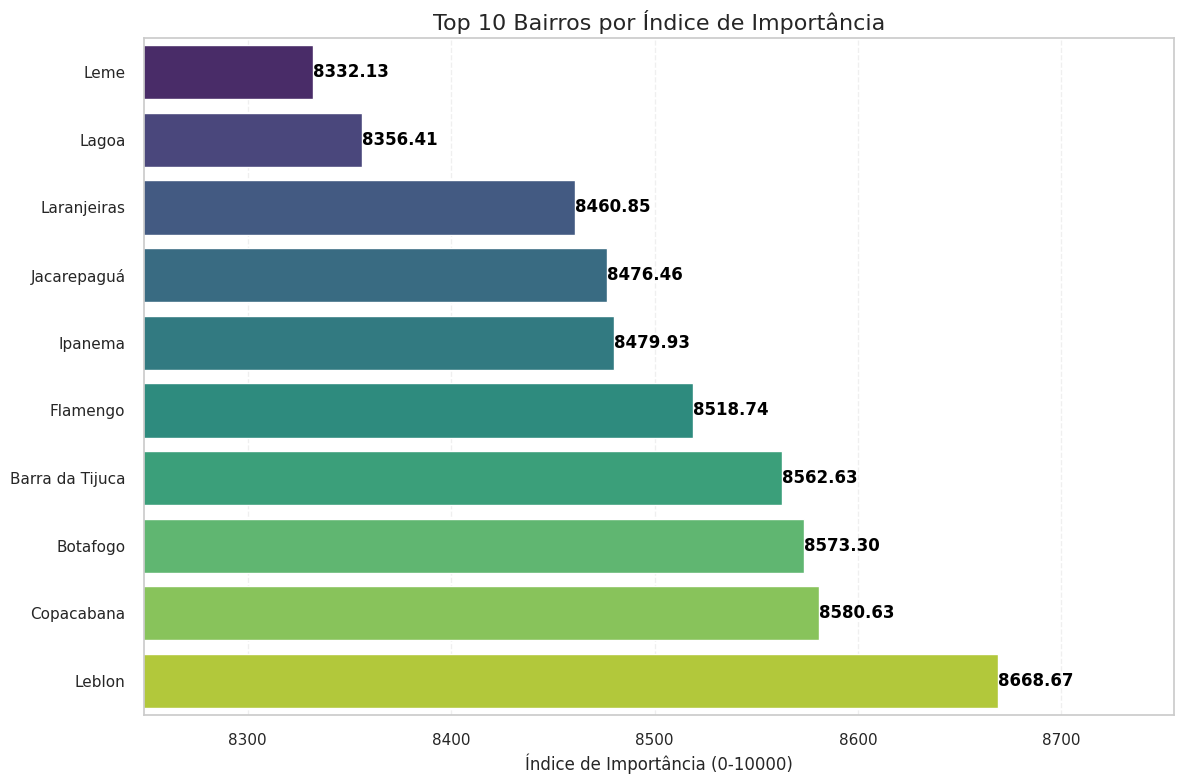

In [306]:
# 1. Calcular métricas-chave por bairro
bairro_stats = df_preco_filtrado.groupby('neighbourhood_cleansed').agg(
    num_imoveis=('id', 'count'),
    preco_medio=('price', 'median'),
    preco_total=('price', 'sum'),
    avaliacao_media=('review_scores_rating', 'mean')
).reset_index()

# 2. Criar índice composto de importância (0-100)
bairro_stats['indice_importancia'] = (
    bairro_stats['num_imoveis'].rank(pct=True) * 40 +
    bairro_stats['preco_total'].rank(pct=True) * 30 +
    bairro_stats['avaliacao_media'].rank(pct=True) * 20 +
    bairro_stats['preco_medio'].rank(pct=True) * 10
) * 100

# 3. Selecionar os 10 bairros mais importantes
top_bairros = bairro_stats.sort_values('indice_importancia', ascending=False).head(10)
print("Top 10 Bairros Mais Importantes:")
display(top_bairros[['neighbourhood_cleansed', 'indice_importancia']])

# 4. Filtrar o DataFrame principal
df_top = df_preco_filtrado[df_preco_filtrado['neighbourhood_cleansed'].isin(top_bairros['neighbourhood_cleansed'])]
print(f"\nDataFrame filtrado: {len(df_top)} imóveis ({len(df_top)/len(df_preco_filtrado):.1%} do total)")

# 5. Gera o gráfico
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='indice_importancia',
    y='neighbourhood_cleansed',
    data=top_bairros.sort_values('indice_importancia', ascending=True),
    palette='viridis',
    orient='h'
)

# Adiciona valores REAIS
for i, v in enumerate(top_bairros.sort_values('indice_importancia', ascending=True)['indice_importancia']):
    ax.text(v, i, f"{v:.2f}", color='black', va='center', fontweight='bold')

plt.title('Top 10 Bairros por Índice de Importância', fontsize=16)
plt.xlabel('Índice de Importância (0-10000)')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.xlim(top_bairros['indice_importancia'].min()*0.99, top_bairros['indice_importancia'].max()*1.01)
plt.tight_layout()
plt.show()

O gráfico e o índice de importância ajudam a priorizar bairros com base em fatores como a oferta de imóveis, preço médio e avaliações dos moradores. Bairros com maior número de imóveis, maior preço total e boa avaliação dos moradores tendem a ter um índice de importância mais alto, refletindo sua relevância no mercado imobiliário.

2. A proximidade de pontos turísticos (praias e Cristo Redentor) influencia o preço mais do que o tipo de imóvel?

Antes de verificar as distâncias, vamos ver se existe algum outlier nas coordenadas do dataset:

In [307]:
# Limites aproximados do Rio de Janeiro
RIO_LAT_MIN, RIO_LAT_MAX = -23.12, -22.54
RIO_LON_MIN, RIO_LON_MAX = -43.80, -43.10

# Função para identificar coordenadas fora do esperado
def verifica_coordenadas(df, lat_col='latitude', lon_col='longitude'):
    # Coordenadas inválidas (fora dos limites do Rio)
    condicoes_invalidas = (
        (df[lat_col] < RIO_LAT_MIN) | (df[lat_col] > RIO_LAT_MAX) |
        (df[lon_col] < RIO_LON_MIN) | (df[lon_col] > RIO_LON_MAX)
    )

    # DataFrame com linhas suspeitas
    df_invalido = df[condicoes_invalidas].copy()
    df_invalido['erro'] = 'Coordenada fora dos limites do Rio'

    return df_invalido

# Aplicar a verificação
df_coordenadas_invalidas = verifica_coordenadas(df_preco_filtrado)
print(f"Coordenadas suspeitas encontradas: {len(df_coordenadas_invalidas)}")
display(df_coordenadas_invalidas[['latitude', 'longitude']].head())

Coordenadas suspeitas encontradas: 0


,latitude,longitude


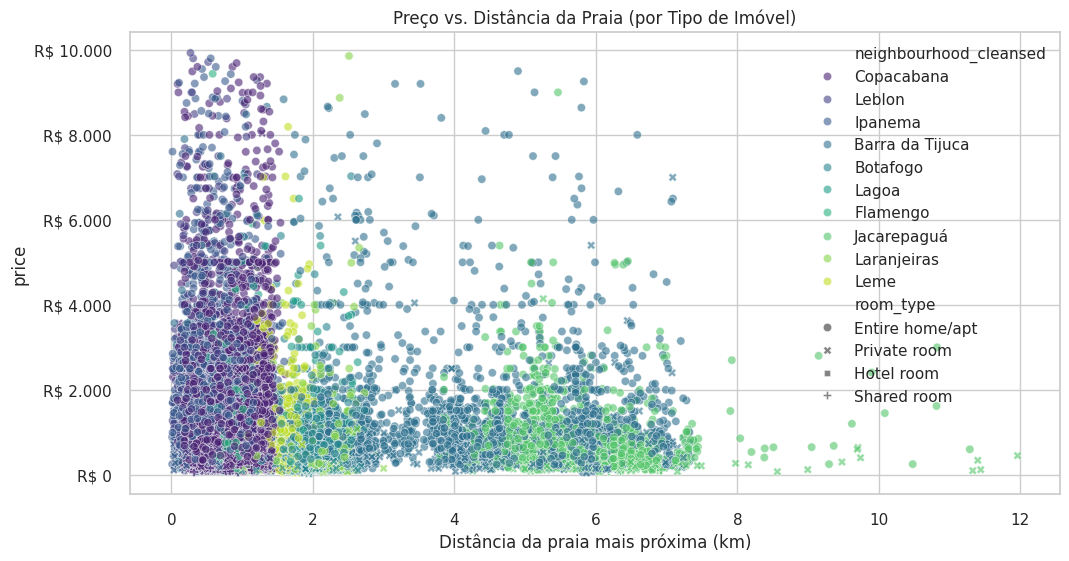

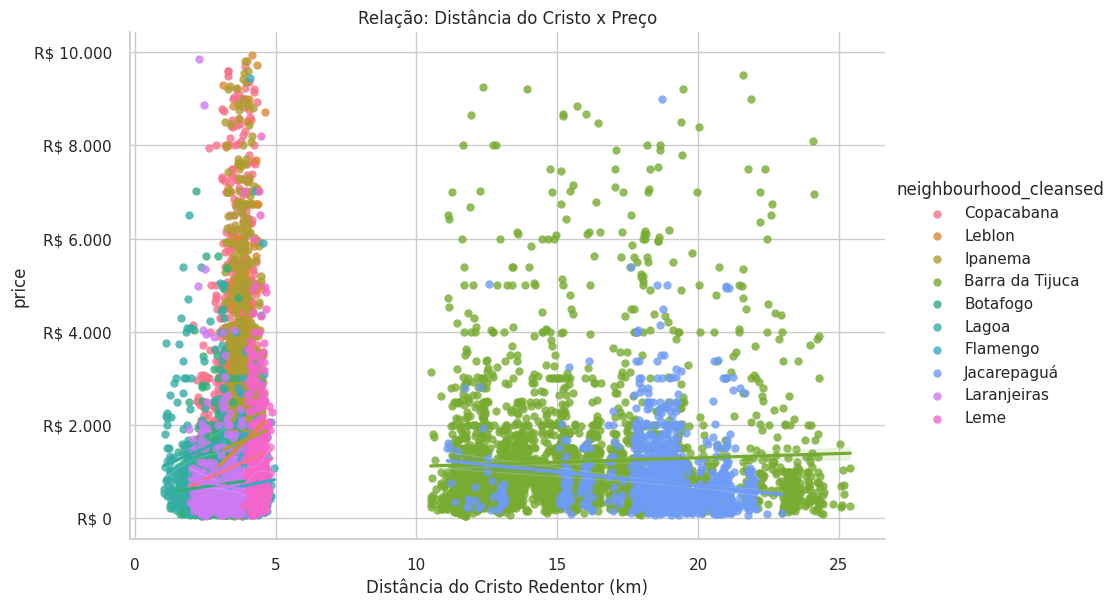

In [308]:
# Dicionário com coordenadas das praias
praias_rio = {
    'Copacabana': (-22.970722, -43.182365),
    'Ipanema': (-22.984218, -43.203631),
    'Leblon': (-22.987457, -43.226969),
    'Barra da Tijuca': (-23.010399, -43.366566),
    'Flamengo': (-22.934137, -43.169807),
    'Recreio dos Bandeirantes': (-23.0260, -43.4769)
}

# Coordenadas Cristo Redentor
cristo = (-22.9519, -43.2106)

# Funções para calcular distâncias
def calcular_distancia_praia(lat, lon):
    ponto = (lat, lon)
    distancias = [geodesic(ponto, praia).km for praia in praias_rio.values()]
    return min(distancias)

def calcular_distancia_cristo(lat, lon):
    ponto = (lat, lon)
    return geodesic(ponto, cristo).km  # Calcula direto a distância para o Cristo

# Aplicar ao DataFrame
df_top['distancia_praia'] = df_top.apply(
    lambda row: calcular_distancia_praia(row['latitude'], row['longitude']), axis=1)

df_top['distancia_cristo'] = df_top.apply(
    lambda row: calcular_distancia_cristo(row['latitude'], row['longitude']), axis=1)

# Gráfico para praia
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='distancia_praia',
    y='price',
    hue='neighbourhood_cleansed',
    style='room_type',
    data=df_top,
    palette="viridis",
    alpha=0.6
)
plt.gca().yaxis.set_major_formatter(formatter)
plt.title("Preço vs. Distância da Praia (por Tipo de Imóvel)")
plt.xlabel("Distância da praia mais próxima (km)")
plt.show()

# Gráfico para cristo
sns.lmplot(
    x='distancia_cristo',
    y='price',
    hue='neighbourhood_cleansed',
    data=df_top,
    height=6,
    aspect=1.5
)
plt.gca().yaxis.set_major_formatter(formatter)
plt.title("Relação: Distância do Cristo x Preço")
plt.xlabel("Distância do Cristo Redentor (km)")
plt.show()

A proximidade da praia é o fator mais significativo para influenciar os preços, com a maior parte dos imóveis mais caros localizados próximos à praia. O tipo de imóvel também influencia, mas não tem o mesmo peso que a localização.

Já a distância do Cristo Redentor parece afetar os preços de maneira mais complexa do que uma simples relação linear. Há uma tendência de preços mais baixos perto do Cristo e preços mais altos à medida que se afasta, mas o impacto da distância varia conforme o bairro, com bairros mais afastados apresentando maior variação nos preços.

3. Bairros com maior oferta de imóveis tendem a ter preços mais competitivos ou mais altos devido à visibilidade?

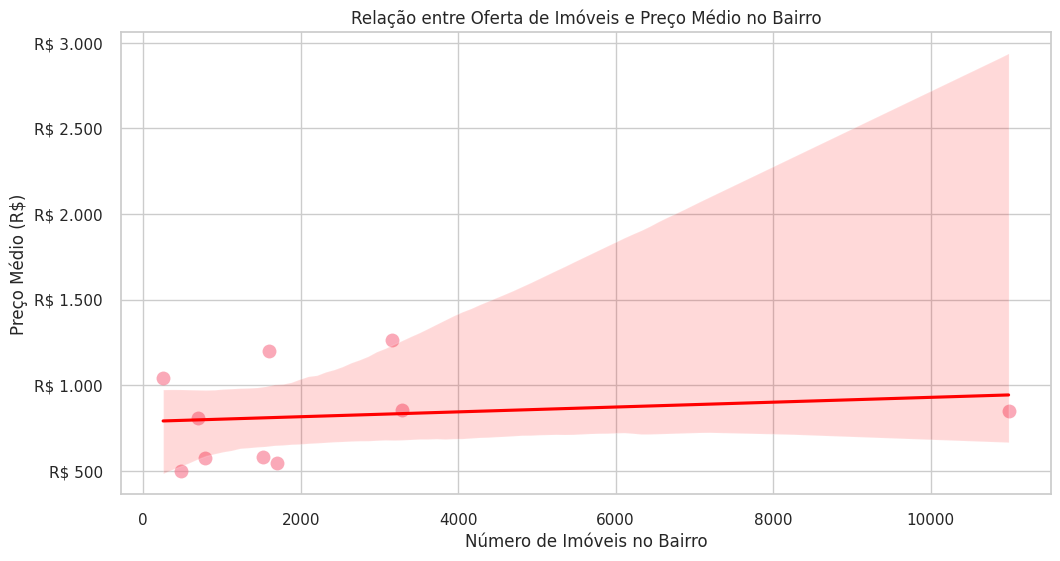

In [309]:
contagem_bairros = df_top['neighbourhood_cleansed'].value_counts().reset_index()
contagem_bairros.columns = ['neighbourhood_cleansed', 'oferta']
preco_medio = df_top.groupby('neighbourhood_cleansed')['price'].median().reset_index()

dados_plot = pd.merge(contagem_bairros, preco_medio, on='neighbourhood_cleansed')

plt.figure(figsize=(12, 6))
sns.regplot(
    x='oferta',

    y='price',
    data=dados_plot,
    scatter_kws={'s': 100, 'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.gca().yaxis.set_major_formatter(formatter)
plt.title("Relação entre Oferta de Imóveis e Preço Médio no Bairro")
plt.xlabel("Número de Imóveis no Bairro")
plt.ylabel("Preço Médio (R$)")
plt.show()

**Análise do gráfico:**

1. Bolas Azuis (Pontos):
Cada ponto representa um bairro, com a posição no eixo X indicando o número de imóveis e a posição no eixo Y representando o preço médio dos imóveis.

Neste gráfico, vemos uma tendência de que, conforme o número de imóveis aumenta, o preço médio também tende a ser mais alto, o que é uma relação positiva.

2. Linha Vermelha (Regressão Linear):
A linha vermelha representa uma linha de regressão linear que foi ajustada aos dados.

Tendência ascendente: A linha de regressão tem uma inclinação positiva, o que significa que existe uma relação positiva entre o número de imóveis e o preço médio. Em outras palavras, bairros com mais imóveis tendem a ter preços médios mais altos.

3. Área Sombreada (Intervalo de Confiança):
A área sombreada ao redor da linha de regressão mostra a incerteza ou variação da linha de regressão. Quanto mais larga a área, maior é a incerteza nas previsões.

A área sombreada está mais estreita nas regiões de maior número de imóveis, o que sugere que a relação entre número de imóveis e preço médio é mais confiável para bairros com mais imóveis.

A variabilidade na relação é maior para bairros com menos imóveis, o que indica que há mais diversidade nos preços para bairros com uma quantidade menor de imóveis.

Relação positiva: A principal descoberta neste gráfico é que bairros com mais imóveis tendem a ter um preço médio mais alto. Isso pode ser devido a vários fatores, como a presença de mais infraestrutura e serviços em bairros com mais imóveis.

Distribuição de preços: A área sombreada indica que há mais incerteza nos preços para bairros com menos imóveis e mais confiança nas previsões para bairros com maior oferta de imóveis.

Possível explicação para essa relação:
Maior oferta, maior preço: Em alguns mercados, bairros com mais imóveis podem ter maior valorização por conta de uma oferta mais diversificada e infraestrutura melhorada.



4.  Imóveis com melhores avaliações mantêm preços mais altos mesmo em bairros menos valorizados?

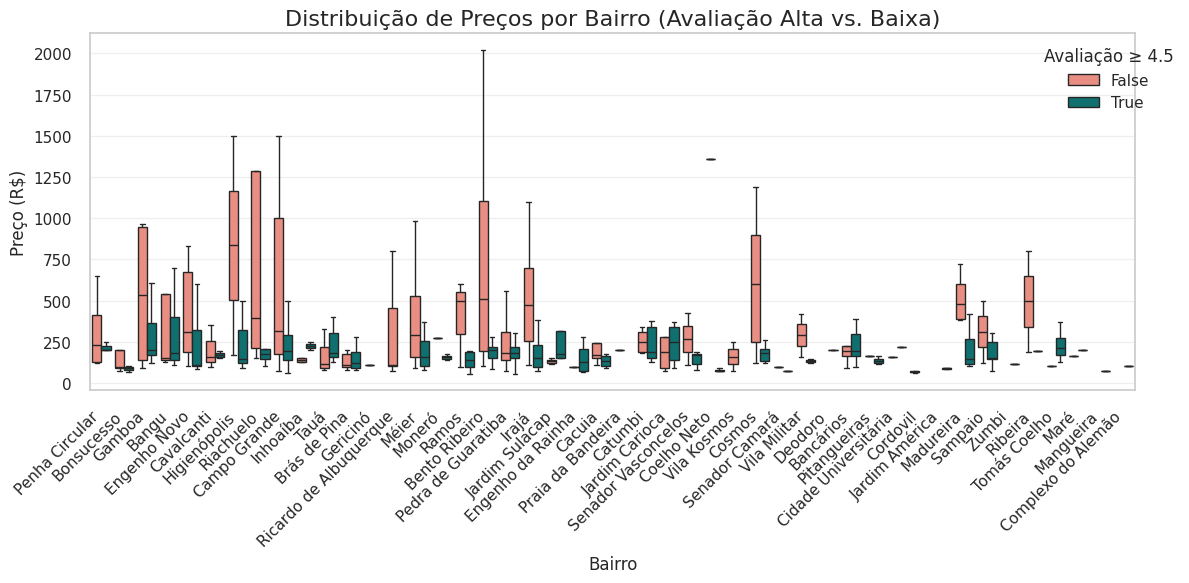

In [310]:
# Definir bairros "menos valorizados" (exemplo: preço mediano abaixo do percentil 30)
limiar_menos_valorizados = df.groupby('neighbourhood_cleansed')['price'].median().quantile(0.3)
bairros_menos_valorizados = df.groupby('neighbourhood_cleansed')['price'].median()[lambda x: x < limiar_menos_valorizados].index.tolist()

# Filtrar dados
df_filtrado = df[df['neighbourhood_cleansed'].isin(bairros_menos_valorizados)].copy()
df_filtrado['high_rating'] = df_filtrado['review_scores_rating'] >= 4.5  # Definir "boa avaliação"

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_filtrado,
    x='neighbourhood_cleansed',
    y='price',
    hue='high_rating',
    palette={True: 'teal', False: 'salmon'},
    showfliers=False  # Remove outliers para melhor visualização
)
plt.title('Distribuição de Preços por Bairro (Avaliação Alta vs. Baixa)', fontsize=16)
plt.xlabel('Bairro', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Avaliação ≥ 4.5', bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Podemos perceber que as avaliações não influenciam nos preços nos bairros menos valorizados, pois os imóveis com avaliações altas tem preços menores que os imóveis com avaliações menores.

5. Imóveis gerenciados por superhosts têm preços consistentemente mais altos do que os demais?

([<matplotlib.axis.XTick at 0x79955838b7d0>,
 [Text(0, 0, 'Não'), Text(1, 0, 'Sim')])

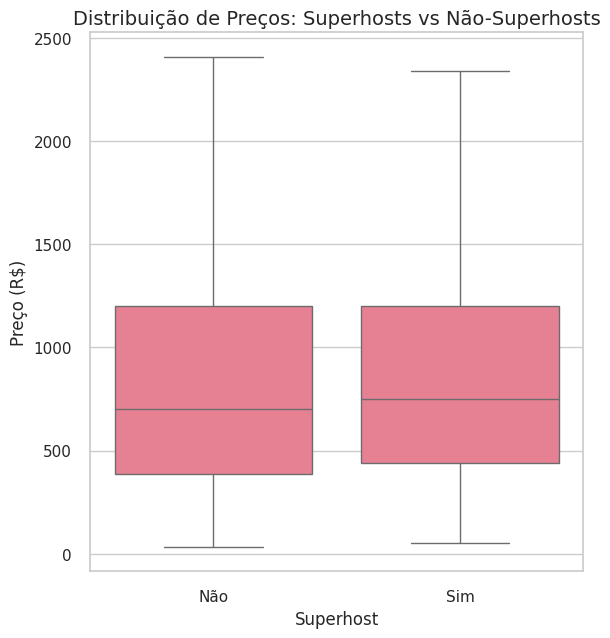

In [311]:
# Configurações iniciais
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

# 1. Pré-processamento
df_preco_filtrado['is_superhost'] = df_preco_filtrado['host_is_superhost'] == 't'

# 2. Análise Visual
plt.figure(figsize=(14, 7))

# Gráfico
plt.subplot(1, 2, 1)
sns.boxplot(x='is_superhost', y='price', data=df_preco_filtrado, showfliers=False)
plt.title('Distribuição de Preços: Superhosts vs Não-Superhosts', fontsize=14)
plt.xlabel('Superhost', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.xticks([0, 1], ['Não', 'Sim'])


Podemos perceber que o fato do host ser um superhost não influencia nos preços dos imóveis.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

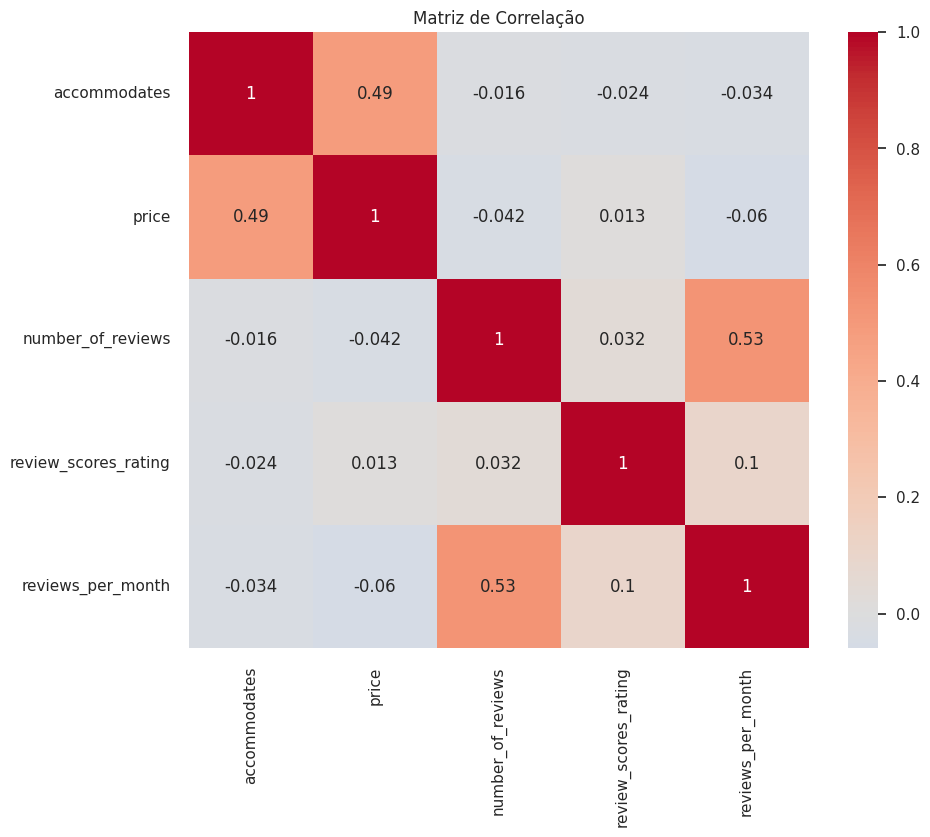

In [312]:
# Selecionando apenas colunas numéricas relevantes para correlação
relevant_columns = [
    'accommodates', 'price',
    'number_of_reviews', 'review_scores_rating',
    'reviews_per_month']

# Filtrando o dataframe
numeric_df = df_top[relevant_columns]

# Calculando a correlação
correlation_matrix = numeric_df.corr()

# Visualizando de forma mais bonita (opcional)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

Preço e número de acomodações: Há uma correlação moderada, sugerindo que imóveis maiores (que acomodam mais pessoas) tendem a ter preços mais altos.

Relação entre avaliações e preço: As variáveis de avaliações (number_of_reviews e reviews_per_month) estão mais fortemente relacionadas entre si do que com o preço.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [313]:
# Separar features (X) e target (y)
X = df.drop('price', axis=1)
y = df['price']

In [314]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [315]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (24904, 10)
Dimensões de X_test: (10674, 10)
Dimensões de y_train: (24904,)
Dimensões de y_test: (10674,)


O conjunto de treino representa 70% do dataset e o de teste representa 30% desse mesmo dataset.

## One hot encoding

Vamos aplicar o one hot encoding nos dados de host_is_superhost e room_type



In [316]:
X_train['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})

# Isso criará duas colunas: 'is_superhost_t' e 'is_superhost_f'
X_train = pd.get_dummies(df, columns=['host_is_superhost'], prefix='is_superhost')

# Criar o encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' evita multicolinearidade

# Ajustar e transformar a coluna
encoded_data = encoder.fit_transform(df[['host_is_superhost']])

# Converter para DataFrame e adicionar ao original
df_encoded = pd.DataFrame(encoded_data, columns=['is_superhost_t'])  # só 't' será representado (evitando redundância)
df = pd.concat([df, df_encoded], axis=1)

In [317]:
X_train = pd.get_dummies(df, columns=['room_type'], prefix='room')

# Criar o encoder (opção drop='first' para evitar multicolinearidade)
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop=None mantém todas as categorias

# Ajustar e transformar a coluna
encoded_data = encoder.fit_transform(df[['room_type']])

# Obter os nomes das colunas
categories = encoder.categories_[0][1:] if encoder.drop_idx_ is not None else encoder.categories_[0]
column_names = [f"room_{cat}" for cat in categories]

# Adicionar ao DataFrame original
df_encoded = pd.DataFrame(encoded_data, columns=column_names)
df = pd.concat([df, df_encoded], axis=1)

# Conclusão

O dataset listings apresentou outliers que representavam claramente erro de digitação, valores faltantes de preço e de superhost que puderam ser removidos devido à sua baixa representatividade e valores faltantes que puderam ser preenchidos porque tinham correlação com o número de avaliações.

A verificação para fazer esses preenchimentos foi bem simples, porque só havia nulos onde não havia avaliação, ou seja, onde o número de avaliações era zero. Logo, pudemos preencher as notas das avaliações com NaN (uma vez que não houve avaliação, não podemos imputar um número) e a média de avaliações por mês com zero (nesse caso faz sentido, porque a média de zero avaliações é zero).

Também conseguimos responder todas as hipóteses, mas, para alguns casos, precisamos filtrar pelos bairros mais significativos, porque alguns gráficos ficaram muito poluídos.

Não foi necessária a realização de normalização e padronização, uma vez que aplicamos o one hot encoding.